<a href="https://colab.research.google.com/github/jothigup/weather-prediction-RDU/blob/daniel-linear-regression/linear_regression_updated_Yaari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RDU hourly temperature — linear regression (fixed pipeline)

Predicts hourly RDU temperature for Sep 17 – Sep 30, 2026 from one GFS run issued before Sep 17 12am.

**What changed from the first version**
1. Actuals are cut off at Sep 17 12am immediately after loading (project rule).
2. Training uses the same GFS cycle as the forecast we predict from (18Z) and covers lead days 1–15.
3. One regression per lead day, so the weight on the GFS forecast can shrink as lead time grows.
4. `day_sin`/`day_cos` are replaced by a climatology built from 2018–2025 RDU observations. The model works on anomalies (departure from the normal for that hour and date).
5. Evaluation is rolling-origin over forecast runs, with a purge gap, instead of one small midsummer validation block.
6. The notebook finishes the job: refit on everything, predict the 336 target hours, save a CSV.

In [26]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## 1. Settings

In [27]:
ACTUAL_PATH  = 'RDU_ACTUAL_HISTORICAL.csv'
FUTURE_PATH  = 'FORECAST_FUTURE.csv'
RUNS_CACHE   = 'gfs_runs_18z.csv'        # downloaded runs are cached here

CUTOFF       = pd.Timestamp('2026-09-17 00:00')   # no data at or after this (Eastern)
TARGET_START = pd.Timestamp('2026-09-17 00:00')
TARGET_END   = pd.Timestamp('2026-09-30 23:00')

RUN_HOUR_UTC = 18                         # FORECAST_FUTURE.csv starts 2pm EDT = 18Z
FIRST_RUN    = '2026-04-03'
LAST_RUN     = '2026-09-16'               # the Sep 16 18Z run is the one we forecast from
MAX_LEAD_DAYS = 15                        # Sep 30 11pm is 345 h after the run -> lead day 15
CLIMO_YEARS  = (2018, 2025)               # climatology never sees 2026

LAT, LON = 35.88, -78.79

# 'api'  = use the Sep 16 18Z run from the same API/model as training (recommended)
# 'csv'  = use FORECAST_FUTURE.csv
FUTURE_SOURCE = 'api'

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

## 2. Actual RDU temperature (cut off at Sep 17 12am)

In [28]:
actual = pd.read_csv(ACTUAL_PATH, low_memory=False)
actual = actual.rename(columns={'valid': 'time'})
actual['time'] = pd.to_datetime(actual['time'])
actual['tmpf'] = pd.to_numeric(actual['tmpf'], errors='coerce')
actual = actual.dropna(subset=['tmpf'])

# The 12:51 observation is labelled 1:00. If the grader labels it 12:00
# instead, change .dt.round('h') to .dt.floor('h') here and nowhere else.
actual['time'] = actual['time'].dt.round('h')

actual_hourly = (actual.groupby('time', as_index=False)['tmpf'].mean()
                       .rename(columns={'tmpf': 'actual_temp'}))

# PROJECT RULE: nothing from Sep 17 12am onward
actual_hourly = actual_hourly[actual_hourly['time'] < CUTOFF].reset_index(drop=True)

print(actual_hourly['time'].min(), '->', actual_hourly['time'].max())
assert actual_hourly['time'].max() < CUTOFF

2018-01-01 01:00:00 -> 2026-09-16 23:00:00


## 3. Climatology (the "normal" temperature for each hour and date)

A small linear regression on yearly and daily harmonics, fit on 2018–2025 only.
It replaces `day_sin`/`day_cos`, which could not learn a season from 3 months of data.

In [29]:
def climo_design(times):
    times = pd.DatetimeIndex(times)
    doy = 2 * np.pi * times.dayofyear.values / 365.25
    hr  = 2 * np.pi * times.hour.values / 24
    year_terms = [np.ones(len(times)), np.sin(doy), np.cos(doy), np.sin(2*doy), np.cos(2*doy)]
    day_terms  = [np.ones(len(times)), np.sin(hr),  np.cos(hr),  np.sin(2*hr),  np.cos(2*hr)]
    # every yearly term x every daily term (lets the daily range change by season)
    cols = [y * d for y in year_terms for d in day_terms]
    return np.column_stack(cols[1:])      # drop the constant; the model has an intercept

climo_data = actual_hourly[actual_hourly['time'].dt.year.between(*CLIMO_YEARS)]
climo_model = LinearRegression().fit(climo_design(climo_data['time']), climo_data['actual_temp'])

def climo(times):
    return climo_model.predict(climo_design(times))

print('Climatology fit RMSE:', round(rmse(climo_data['actual_temp'], climo(climo_data['time'])), 2), '°F')
print('Normal for Sep 17 3pm:', round(climo([pd.Timestamp('2026-09-17 15:00')])[0], 1),
      '| Sep 30 6am:', round(climo([pd.Timestamp('2026-09-30 06:00')])[0], 1))

Climatology fit RMSE: 8.48 °F
Normal for Sep 17 3pm: 82.4 | Sep 30 6am: 60.8


## 4. Download one 18Z GFS run per day (cached)

In [30]:
API_URL = 'https://single-runs-api.open-meteo.com/v1/forecast'
RENAME = {'temperature_2m': 'forecast_temp', 'precipitation': 'precipitation',
          'cloud_cover': 'cloud_cover', 'wind_speed_10m': 'wind_speed',
          'wind_direction_10m': 'wind_direction'}

def fetch_run(run_time):
    params = {'latitude': LAT, 'longitude': LON,
              'run': run_time.strftime('%Y-%m-%dT%H:%M'),
              'hourly': list(RENAME.keys()),
              'models': 'gfs_global', 'forecast_days': 16,
              'temperature_unit': 'fahrenheit', 'wind_speed_unit': 'mph',
              'precipitation_unit': 'inch', 'timezone': 'GMT'}
    r = requests.get(API_URL, params=params, timeout=30)
    r.raise_for_status()
    out = pd.DataFrame(r.json()['hourly']).rename(columns=RENAME)
    out['time'] = pd.to_datetime(out['time'])
    out['run_time'] = run_time
    return out

run_times = pd.date_range(FIRST_RUN, LAST_RUN, freq='D') + pd.Timedelta(hours=RUN_HOUR_UTC)

if os.path.exists(RUNS_CACHE):
    gfs = pd.read_csv(RUNS_CACHE, parse_dates=['time', 'run_time'])
    print('Loaded cache:', RUNS_CACHE)
else:
    all_runs, failed = [], []
    for rt in run_times:
        try:
            all_runs.append(fetch_run(rt))
        except Exception as e:
            failed.append((rt, str(e)[:80]))
        time.sleep(0.1)
    print('Successful runs:', len(all_runs), '| Failed:', len(failed), failed[:3])
    gfs = pd.concat([d for d in all_runs if d['forecast_temp'].notna().any()], ignore_index=True)
    gfs.to_csv(RUNS_CACHE, index=False)

print(gfs.shape, '| runs:', gfs['run_time'].nunique(),
      '|', gfs['run_time'].min(), '->', gfs['run_time'].max())

Loaded cache: gfs_runs_18z.csv
(63744, 7) | runs: 166 | 2026-04-03 18:00:00 -> 2026-09-16 18:00:00


## 5. Features (the same function is used for training and for the final forecast)

In [31]:
def add_features(d):
    """d needs: time (Eastern), lead_hours, forecast_temp, precipitation,
    cloud_cover, wind_speed, wind_direction."""
    d = d.copy()
    d['lead_day'] = (d['lead_hours'] // 24).astype(int) + 1
    d['precipitation'] = d['precipitation'].fillna(0)      # hour 0 of a run has no precip total
    d['climo'] = climo(d['time'])
    d['fc_anom'] = d['forecast_temp'] - d['climo']          # how unusual GFS says it will be
    wd = np.deg2rad(d['wind_direction'])
    d['wind_sin'], d['wind_cos'] = np.sin(wd), np.cos(wd)
    hr = 2 * np.pi * d['time'].dt.hour / 24
    d['hour_sin'],  d['hour_cos']  = np.sin(hr),   np.cos(hr)
    d['hour_sin2'], d['hour_cos2'] = np.sin(2*hr), np.cos(2*hr)
    return d

FEATURES = ['fc_anom', 'cloud_cover', 'precipitation', 'wind_speed',
            'wind_sin', 'wind_cos', 'hour_sin', 'hour_cos', 'hour_sin2', 'hour_cos2']

g = gfs.copy()
g['lead_hours'] = (g['time'] - g['run_time']).dt.total_seconds() / 3600
g = g[(g['lead_hours'] >= 0) & (g['lead_hours'] < MAX_LEAD_DAYS * 24)]

# valid time UTC -> Eastern (to match the RDU observations)
g['time'] = (g['time'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None))

g = add_features(g).dropna(subset=FEATURES)

# The run we will forecast from (kept separate; it has no actuals)
future_run_time = pd.Timestamp(LAST_RUN) + pd.Timedelta(hours=RUN_HOUR_UTC)
api_future = g[g['run_time'] == future_run_time].copy()

# Training table: forecasts joined to actuals. Because actuals stop at the
# cutoff, no row here can contain a Sep 17+ observation.
model_df = g.merge(actual_hourly, on='time', how='inner')
model_df['target_anom'] = model_df['actual_temp'] - model_df['climo']
assert model_df['time'].max() < CUTOFF

print(model_df.shape)
print(model_df.groupby('lead_day').size().to_string())

(56774, 19)
lead_day
1     3798
2     3940
3     3916
4     3892
5     3868
6     3844
7     3820
8     3796
9     3772
10    3748
11    3724
12    3700
13    3676
14    3652
15    3628


## 6. Model: one linear regression per lead day

`actual anomaly = a + b * GFS anomaly + (cloud, rain, wind, hour-of-day terms)`

Fitting it separately for each lead day lets `b` fall toward 0 at long leads, which means
"trust the normal more, trust GFS less".

In [32]:
def fit_models(train):
    return {day: LinearRegression().fit(grp[FEATURES], grp['target_anom'])
            for day, grp in train.groupby('lead_day')}

def predict(models, d):
    pred = pd.Series(np.nan, index=d.index)
    for day, grp in d.groupby('lead_day'):
        if day in models:
            pred.loc[grp.index] = models[day].predict(grp[FEATURES]) + grp['climo']
    return pred

## 7. Evaluation: rolling-origin backtest

Each fold tests on a block of later runs. Training runs must end 15 days before the block starts,
so no training forecast overlaps a test period. Compared against raw GFS and climatology alone.

In [33]:
N_FOLDS, RUNS_PER_FOLD = 4, 20
runs = np.sort(model_df['run_time'].unique())
purge = pd.Timedelta(days=MAX_LEAD_DAYS)

fold_rows, scored = [], []
for k in range(N_FOLDS):
    hi = len(runs) - (N_FOLDS - 1 - k) * RUNS_PER_FOLD
    test_runs = runs[hi - RUNS_PER_FOLD:hi]
    train = model_df[model_df['run_time'] <= test_runs[0] - purge]
    test  = model_df[model_df['run_time'].isin(test_runs)].copy()
    test['lr_pred'] = predict(fit_models(train), test)
    test = test.dropna(subset=['lr_pred'])
    test['fold'] = k + 1
    scored.append(test)
    fold_rows.append({'fold': k + 1,
                      'train_runs': train['run_time'].nunique(),
                      'test_runs': f"{pd.Timestamp(test_runs[0]).date()} -> {pd.Timestamp(test_runs[-1]).date()}",
                      'raw_GFS': rmse(test['actual_temp'], test['forecast_temp']),
                      'climatology': rmse(test['actual_temp'], test['climo']),
                      'linear_reg': rmse(test['actual_temp'], test['lr_pred'])})

scored = pd.concat(scored)
fold_table = pd.DataFrame(fold_rows).round(3)
print(fold_table.to_string(index=False))
print('\nAll folds pooled  | raw GFS: %.3f | climatology: %.3f | linear regression: %.3f'
      % (rmse(scored['actual_temp'], scored['forecast_temp']),
         rmse(scored['actual_temp'], scored['climo']),
         rmse(scored['actual_temp'], scored['lr_pred'])))

 fold  train_runs                test_runs  raw_GFS  climatology  linear_reg
    1          72 2026-06-29 -> 2026-07-18    6.605        5.980       6.368
    2          92 2026-07-19 -> 2026-08-07    5.751        4.416       4.367
    3         112 2026-08-08 -> 2026-08-27    6.357        5.333       5.073
    4         132 2026-08-28 -> 2026-09-16    5.719        6.529       4.365

All folds pooled  | raw GFS: 6.161 | climatology: 5.516 | linear regression: 5.181


          raw_GFS  climatology  linear_reg
lead_day                                  
1           3.521        5.583       3.460
2           4.042        5.658       4.001
3           4.445        5.678       4.173
4           4.804        5.660       4.460
5           4.793        5.592       4.358
6           5.083        5.481       4.906
7           6.087        5.378       5.466
8           6.137        5.382       5.372
9           6.575        5.403       5.515
10          7.213        5.435       5.884
11          7.164        5.469       6.505
12          7.033        5.454       5.546
13          7.975        5.474       5.644
14          8.018        5.510       6.471
15          8.032        5.521       5.448


/tmp/ipykernel_7700/3791844162.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_lead = scored.groupby('lead_day').apply(lambda t: pd.Series({


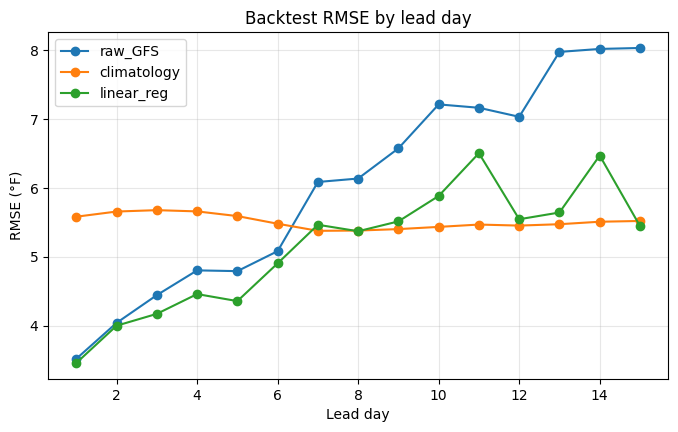

In [34]:
by_lead = scored.groupby('lead_day').apply(lambda t: pd.Series({
    'raw_GFS': rmse(t['actual_temp'], t['forecast_temp']),
    'climatology': rmse(t['actual_temp'], t['climo']),
    'linear_reg': rmse(t['actual_temp'], t['lr_pred'])})).round(3)
print(by_lead.to_string())

by_lead.plot(marker='o', figsize=(8, 4.5))
plt.xlabel('Lead day'); plt.ylabel('RMSE (°F)')
plt.title('Backtest RMSE by lead day'); plt.grid(alpha=0.3); plt.show()

## 8. Final model: refit on all runs, then look at how much it trusts GFS at each lead

In [35]:
final_models = fit_models(model_df)

weights = pd.Series({day: m.coef_[FEATURES.index('fc_anom')] for day, m in final_models.items()})
print('Weight on the GFS anomaly by lead day (1 = trust fully, 0 = ignore):')
print(weights.round(2).to_string())

Weight on the GFS anomaly by lead day (1 = trust fully, 0 = ignore):
1     0.92
2     0.88
3     0.82
4     0.83
5     0.74
6     0.69
7     0.61
8     0.57
9     0.46
10    0.35
11    0.32
12    0.34
13    0.22
14    0.12
15    0.10


## 9. Forecast Sep 17 – Sep 30 and save

In [36]:
# FORECAST_FUTURE.csv: one run, first row is the run start (2pm EDT = 18Z)
csv_future = pd.read_csv(FUTURE_PATH, skiprows=3)
csv_future = csv_future.rename(columns={
    'temperature_2m (°F)': 'forecast_temp', 'precipitation (inch)': 'precipitation',
    'cloud_cover (%)': 'cloud_cover', 'wind_speed_10m (mp/h)': 'wind_speed',
    'wind_direction_10m (°)': 'wind_direction'})
csv_future['time'] = pd.to_datetime(csv_future['time'])
csv_future['lead_hours'] = (csv_future['time'] - csv_future['time'].min()).dt.total_seconds() / 3600
csv_future = add_features(csv_future)

# Is the CSV the same forecast as the API run the model was trained on?
if len(api_future):
    both = api_future.merge(csv_future, on='time', suffixes=('_api', '_csv'))
    diff = (both['forecast_temp_api'] - both['forecast_temp_csv']).abs()
    print('API run vs FORECAST_FUTURE.csv temperature: mean |diff| = %.2f°F, max = %.2f°F'
          % (diff.mean(), diff.max()))

future = api_future if (FUTURE_SOURCE == 'api' and len(api_future)) else csv_future
print('Forecasting from:', 'API run ' + str(future_run_time) + 'Z' if future is api_future else FUTURE_PATH)

future = future[(future['time'] >= TARGET_START) & (future['time'] <= TARGET_END)].copy()
future['predicted_temp'] = predict(final_models, future)

assert len(future) == 336, f'expected 336 target hours, got {len(future)}'
assert future['predicted_temp'].notna().all(), 'some target hours have no prediction'

out = future[['time', 'forecast_temp', 'climo', 'predicted_temp']].rename(
    columns={'forecast_temp': 'raw_gfs_temp', 'climo': 'climatology_temp'})
out[out.columns[1:]] = out[out.columns[1:]].round(2)
out.to_csv('lr_predictions_sep17_30.csv', index=False)
print(out.head()); print(out.tail())

API run vs FORECAST_FUTURE.csv temperature: mean |diff| = 0.00°F, max = 0.00°F
Forecasting from: API run 2026-09-16 18:00:00Z
                     time  raw_gfs_temp  climatology_temp  predicted_temp
63370 2026-09-17 00:00:00          70.6             68.63           72.55
63371 2026-09-17 01:00:00          69.5             67.90           71.26
63372 2026-09-17 02:00:00          68.0             67.17           69.68
63373 2026-09-17 03:00:00          66.8             66.41           68.43
63374 2026-09-17 04:00:00          65.9             65.69           67.50
                     time  raw_gfs_temp  climatology_temp  predicted_temp
63701 2026-09-30 19:00:00          69.2             72.00           73.66
63702 2026-09-30 20:00:00          68.9             69.78           71.63
63703 2026-09-30 21:00:00          68.8             67.89           69.81
63704 2026-09-30 22:00:00          68.8             66.44           68.30
63705 2026-09-30 23:00:00          68.6             65.40   

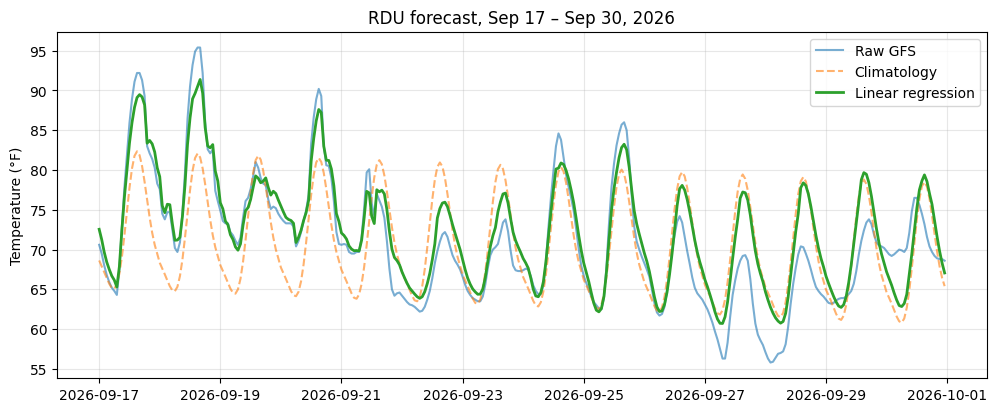

In [37]:
plt.figure(figsize=(12, 4.5))
plt.plot(out['time'], out['raw_gfs_temp'], label='Raw GFS', alpha=0.6)
plt.plot(out['time'], out['climatology_temp'], label='Climatology', alpha=0.6, linestyle='--')
plt.plot(out['time'], out['predicted_temp'], label='Linear regression', linewidth=2)
plt.ylabel('Temperature (°F)'); plt.title('RDU forecast, Sep 17 – Sep 30, 2026')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [38]:
# Fetch RDU temperatures for Sep 16 - Oct 1 straight from the Iowa Mesonet (scoring only)
url = ("https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
       "?station=RDU&data=tmpf"
       "&year1=2026&month1=9&day1=16&year2=2026&month2=10&day2=2"
       "&tz=America%2FNew_York&format=onlycomma&latlon=no&missing=M&trace=T"
       "&direct=no&report_type=3&report_type=4")

recent = pd.read_csv(url).rename(columns={'valid': 'time'})
recent['time'] = pd.to_datetime(recent['time']).dt.round('h')
recent['tmpf'] = pd.to_numeric(recent['tmpf'], errors='coerce')
recent = recent.dropna(subset=['tmpf'])
print(recent.shape, '|', recent['time'].min(), '->', recent['time'].max())

# Replace the tail of the actuals with the fresh download
split_at = pd.Timestamp('2026-09-16 12:00')
actual = pd.concat([actual.loc[actual['time'] < split_at, ['time', 'tmpf']],
                    recent.loc[recent['time'] >= split_at, ['time', 'tmpf']]],
                   ignore_index=True)

(418, 3) | 2026-09-16 01:00:00 -> 2026-10-02 00:00:00


Hours compared: 336 | 2026-09-17 00:00:00 -> 2026-09-30 23:00:00
RMSE  linear regression: 6.88°F
RMSE  raw GFS:           7.84°F
RMSE  climatology:       7.61°F
Average error (bias):    +1.10°F
            linear_reg  raw_GFS  climatology
date                                        
2026-09-17        2.05     1.62         7.30
2026-09-18        3.31     3.17         9.89
2026-09-19        4.85     4.66         7.29
2026-09-20        4.04     4.18         7.61
2026-09-21        9.13    10.32         9.51
2026-09-22        5.54     7.46         3.57
2026-09-23        9.18     6.76        10.68
2026-09-24       12.69    13.30        10.88
2026-09-25       10.84    11.59         8.92
2026-09-26        8.81     9.17         7.95
2026-09-27        4.20     7.65         4.31
2026-09-28        2.69     6.82         3.22
2026-09-29        3.33     5.96         4.24
2026-09-30        4.10     8.08         4.93


/tmp/ipykernel_7700/3017813540.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(compare.groupby('date').apply(lambda d: pd.Series({


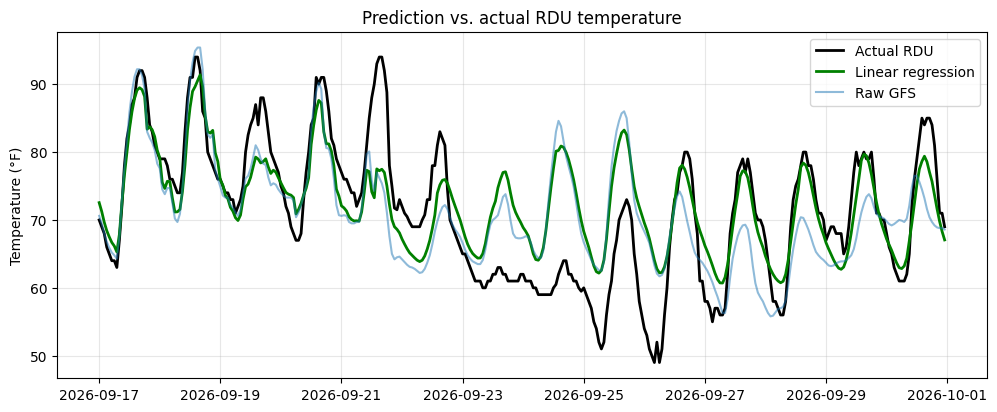

In [39]:
# Actuals for the target window (scoring only -- never used for training)
actual_target = (actual.groupby('time', as_index=False)['tmpf'].mean()
                       .rename(columns={'tmpf': 'actual_temp'}))
actual_target = actual_target[(actual_target['time'] >= TARGET_START) &
                              (actual_target['time'] <= TARGET_END)]

compare = out.merge(actual_target, on='time', how='inner')
compare['error'] = compare['predicted_temp'] - compare['actual_temp']
compare.to_csv('lr_vs_actual.csv', index=False)

print('Hours compared:', len(compare), '|', compare['time'].min(), '->', compare['time'].max())
print('RMSE  linear regression: %.2f°F' % rmse(compare['actual_temp'], compare['predicted_temp']))
print('RMSE  raw GFS:           %.2f°F' % rmse(compare['actual_temp'], compare['raw_gfs_temp']))
print('RMSE  climatology:       %.2f°F' % rmse(compare['actual_temp'], compare['climatology_temp']))
print('Average error (bias):    %+.2f°F' % compare['error'].mean())

# RMSE by day
compare['date'] = compare['time'].dt.date
print(compare.groupby('date').apply(lambda d: pd.Series({
    'linear_reg': rmse(d['actual_temp'], d['predicted_temp']),
    'raw_GFS': rmse(d['actual_temp'], d['raw_gfs_temp']),
    'climatology': rmse(d['actual_temp'], d['climatology_temp'])})).round(2))

plt.figure(figsize=(12, 4.5))
plt.plot(compare['time'], compare['actual_temp'], color='black', linewidth=2, label='Actual RDU')
plt.plot(compare['time'], compare['predicted_temp'], color='green', linewidth=2, label='Linear regression')
plt.plot(compare['time'], compare['raw_gfs_temp'], alpha=0.5, label='Raw GFS')
plt.ylabel('Temperature (°F)'); plt.title('Prediction vs. actual RDU temperature')
plt.legend(); plt.grid(alpha=0.3); plt.show()

RMSE   LR: 6.88 | GFS: 7.84
MAE    LR: 5.25 | GFS: 6.24
LR improvement over GFS: 12.3%
Hours where LR was closer: 54%
               LR    GFS winner
time                           
2026-09-17   2.05   1.62    GFS
2026-09-18   3.31   3.17    GFS
2026-09-19   4.85   4.66    GFS
2026-09-20   4.04   4.18     LR
2026-09-21   9.13  10.32     LR
2026-09-22   5.54   7.46     LR
2026-09-23   9.18   6.76    GFS
2026-09-24  12.69  13.30     LR
2026-09-25  10.84  11.59     LR
2026-09-26   8.81   9.17     LR
2026-09-27   4.20   7.65     LR
2026-09-28   2.69   6.82     LR
2026-09-29   3.33   5.96     LR
2026-09-30   4.10   8.08     LR
winner
LR     10
GFS     4
GFS RMSE minus LR RMSE: 95% range 0.17 to 1.82°F (LR better if the whole range is above 0)

Backtest runs: 80 | LR better in 66 (82%)
Average RMSE per run   LR: 4.84 | GFS: 5.84


/tmp/ipykernel_7700/617294683.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_run = scored.groupby('run_time').apply(lambda r: pd.Series({


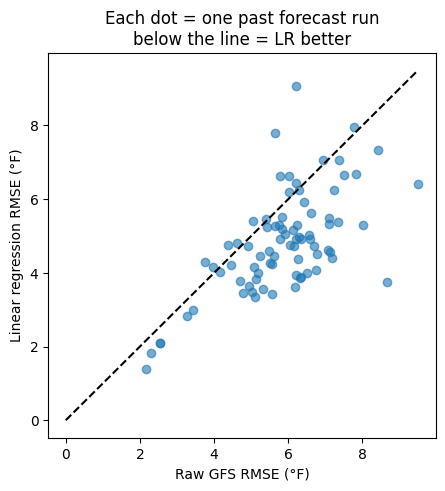

In [40]:
# ---------- 1. This forecast: Sep 17-30 ----------
c = compare.copy()
c['lr_abs']  = (c['predicted_temp'] - c['actual_temp']).abs()
c['gfs_abs'] = (c['raw_gfs_temp']   - c['actual_temp']).abs()

lr_rmse, gfs_rmse = rmse(c['actual_temp'], c['predicted_temp']), rmse(c['actual_temp'], c['raw_gfs_temp'])
print('RMSE   LR: %.2f | GFS: %.2f' % (lr_rmse, gfs_rmse))
print('MAE    LR: %.2f | GFS: %.2f' % (c['lr_abs'].mean(), c['gfs_abs'].mean()))
print('LR improvement over GFS: %.1f%%' % (100 * (1 - lr_rmse / gfs_rmse)))
print('Hours where LR was closer: %.0f%%' % (100 * (c['lr_abs'] < c['gfs_abs']).mean()))

daily = c.groupby(c['time'].dt.date).apply(lambda d: pd.Series({
    'LR': rmse(d['actual_temp'], d['predicted_temp']),
    'GFS': rmse(d['actual_temp'], d['raw_gfs_temp'])}))
daily['winner'] = np.where(daily['LR'] < daily['GFS'], 'LR', 'GFS')
print(daily.round(2)); print(daily['winner'].value_counts().to_string())

# Is the gap bigger than chance? Resample whole days (hours within a day move together)
rng = np.random.default_rng(0)
days = [d for _, d in c.groupby(c['time'].dt.date)]
diffs = []
for _ in range(5000):
    s = pd.concat([days[i] for i in rng.integers(0, len(days), len(days))])
    diffs.append(rmse(s['actual_temp'], s['raw_gfs_temp']) - rmse(s['actual_temp'], s['predicted_temp']))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print('GFS RMSE minus LR RMSE: 95%% range %.2f to %.2f°F (LR better if the whole range is above 0)' % (lo, hi))

# ---------- 2. Many past forecasts: the backtest ----------
per_run = scored.groupby('run_time').apply(lambda r: pd.Series({
    'LR': rmse(r['actual_temp'], r['lr_pred']),
    'GFS': rmse(r['actual_temp'], r['forecast_temp'])}))
print('\nBacktest runs: %d | LR better in %d (%.0f%%)' %
      (len(per_run), (per_run['LR'] < per_run['GFS']).sum(), 100 * (per_run['LR'] < per_run['GFS']).mean()))
print('Average RMSE per run   LR: %.2f | GFS: %.2f' % (per_run['LR'].mean(), per_run['GFS'].mean()))

plt.figure(figsize=(5, 5))
plt.scatter(per_run['GFS'], per_run['LR'], alpha=0.6)
m = per_run.max().max()
plt.plot([0, m], [0, m], 'k--')
plt.xlabel('Raw GFS RMSE (°F)'); plt.ylabel('Linear regression RMSE (°F)')
plt.title('Each dot = one past forecast run\nbelow the line = LR better'); plt.show()